# Cifar10

In this exercise we will try to create a CNN that will classify not 2 but 10 different image labels. We get the images from the dataset named [Cifar10](http://www.cs.utoronto.ca/~kriz/cifar.html) 

* Import :
  * pytorch
  * Numpy 
  * Matplotlib.pyplot 

In [1]:
# Let's load a single image with PyTorch
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


* Load the image files into your storage with this link `https://full-stack-assets.s3.eu-west-3.amazonaws.com/datasets/M08/cifar-10/train.zip`

In [2]:
import os
import requests
import zipfile

# Define the URL and the output path
url = "https://full-stack-assets.s3.eu-west-3.amazonaws.com/datasets/M08/cifar-10/train.zip"
output_path = "train.zip"
extract_dir = "./train"

def load_and_extract_files(url, ouptut_path, extract_dir):
    # Download the dataset
    if not os.path.exists(output_path):
        response = requests.get(url, stream=True)
        with open(ouptut_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    # Extract the dataset
    if not os.path.exists(extract_dir):
        with zipfile.ZipFile(ouptut_path, "r") as zip_ref:
            zip_ref.extractall("./")
        print("Extraction complete.")

load_and_extract_files(url, output_path, extract_dir)

Download complete.
Extraction complete.


* Import the dataframe containing the labels from this link `https://full-stack-assets.s3.eu-west-3.amazonaws.com/datasets/M08/cifar-10/trainLabels.csv`

In [3]:
# Then the DataFrame containing the name of the image files and the value of the 
# target variable


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


* Turn the `id` column into string type and add `.png` at the end of each string for the filenames to be complete

,id,label
0,1.png,frog
1,2.png,truck
2,3.png,truck
3,4.png,deer
4,5.png,automobile


* Load and display an image of your dataset 

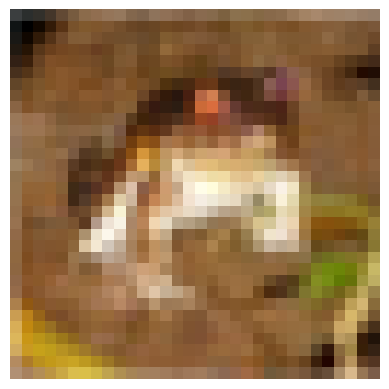

In [5]:
# Visualize a random picture
# Open an image file

# Show the image


* View a random image of each of your labels in your dataset * View a random image of each of your labels in your dataset 

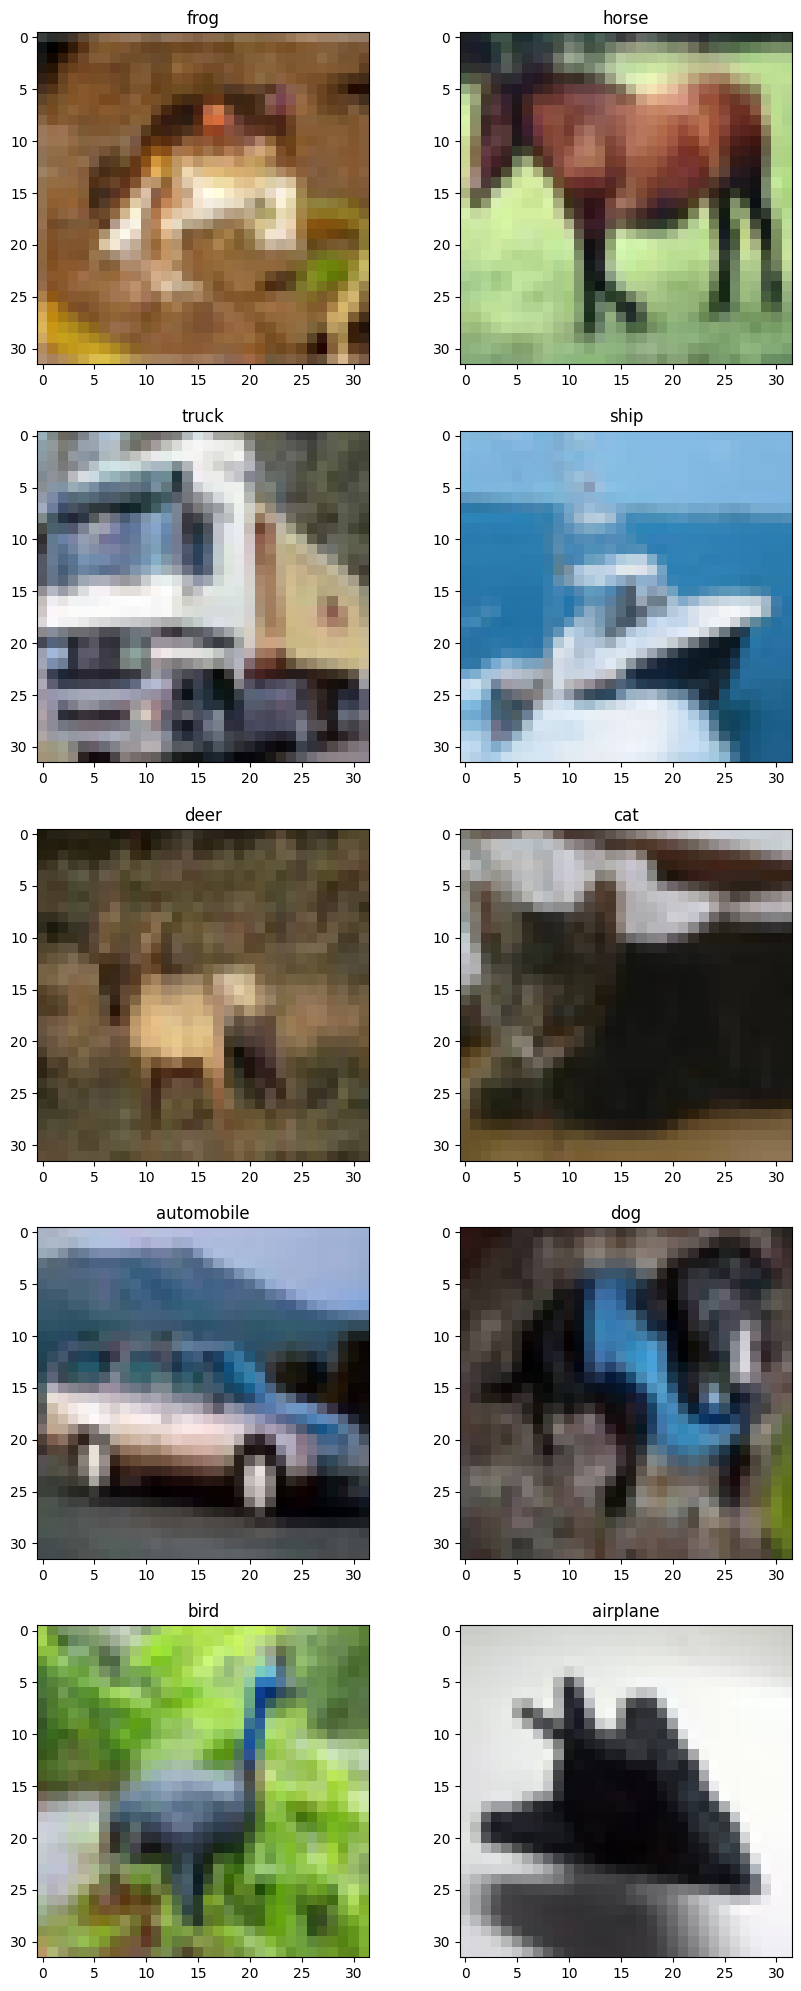

* Define the transformations you will be applying to your images. Use a target size of `(32,32)

In [12]:
from torchvision import datasets

# Apply a series of transformations to the images
# Randomly rotate images up to 180 degrees
# Randomly flip images horizontally
# Randomly flip images vertically
# Randomly adjust brightness and contrast
# Resize images to 32x32 pixels
# Convert images to tensors


* Set up one generator for the train data and one for the test data using the method that lets you generate data with a dataframe. Since we have many images in this dataset, we will create large batches of 64 images.

In [13]:
# Import necessary libraries

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd
from torch.utils.data import Dataset
import os

# Create a dictionary mapping class labels to indices

# Define a custom PyTorch Dataset class for loading images
# Initialize the dataset with a DataFrame, image directory, and optional transformations
# Return the number of samples in the dataset
# Load an image file and retrieve its corresponding label
# Convert label to numerical format using the class dictionary
# Apply transformations if specified
# Return the transformed image and its label

# Create a dataset instance using the DataFrame and image directory

# Split dataset into training (80%) and validation (20%) subsets

# Create DataLoaders for training and validation sets


In [14]:
next(iter(train_loader))

[tensor([[[[0.7412, 0.7333, 0.7333,  ..., 0.7098, 0.7098, 0.7098],
           [0.7451, 0.7373, 0.7373,  ..., 0.7137, 0.7137, 0.7098],
           [0.7490, 0.7412, 0.7412,  ..., 0.7137, 0.7137, 0.7137],
           ...,
           [0.7137, 0.7059, 0.7098,  ..., 0.7059, 0.7255, 0.7020],
           [0.7098, 0.7020, 0.7020,  ..., 0.7922, 0.7686, 0.7804],
           [0.7098, 0.6980, 0.6980,  ..., 0.8118, 0.8118, 0.8157]],
 
          [[0.8039, 0.7961, 0.7961,  ..., 0.7569, 0.7569, 0.7529],
           [0.8078, 0.8000, 0.8000,  ..., 0.7608, 0.7608, 0.7569],
           [0.8118, 0.8039, 0.8039,  ..., 0.7608, 0.7608, 0.7608],
           ...,
           [0.7725, 0.7608, 0.7647,  ..., 0.7412, 0.7608, 0.7412],
           [0.7686, 0.7608, 0.7608,  ..., 0.8235, 0.8039, 0.8157],
           [0.7686, 0.7569, 0.7569,  ..., 0.8431, 0.8431, 0.8431]],
 
          [[0.8039, 0.7961, 0.7961,  ..., 0.7608, 0.7608, 0.7569],
           [0.8078, 0.8000, 0.8000,  ..., 0.7608, 0.7608, 0.7608],
           [0.8118, 0.80

* Display a batch of data of train data

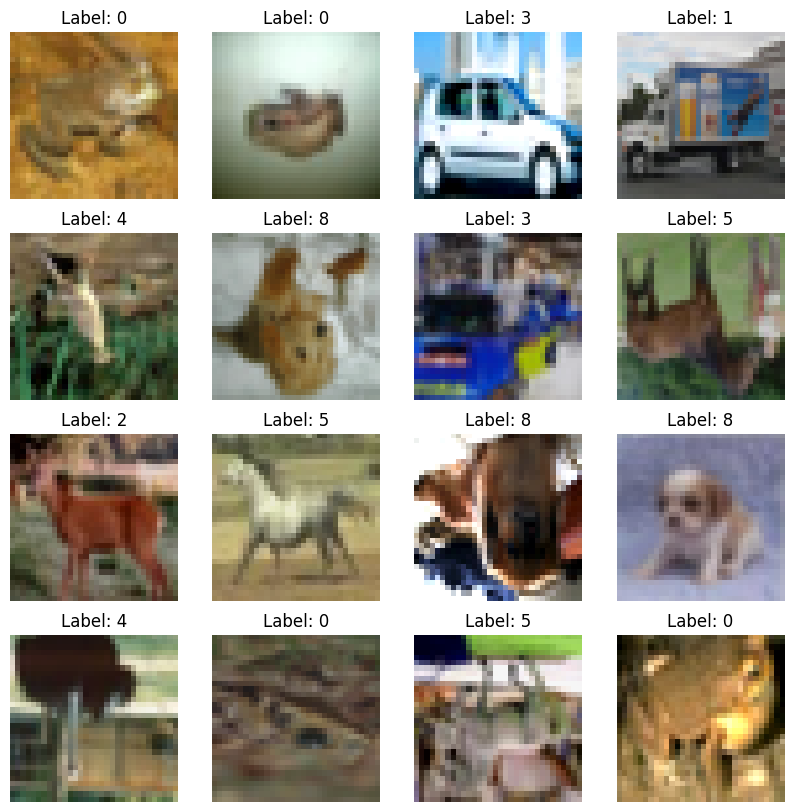

* How many times can you divide the images by two along each axis until you reduce the images to single pixel?

32 -> 16.0
16.0 -> 8.0
8.0 -> 4.0
4.0 -> 2.0
2.0 -> 1.0


* Build a neural network with a single convolution layer with 32 neurons, kernel size `(3,3)`, padding `"same"`, and activation `"relu"`, a max pooling layer, a flatten layer, then finish up the network with a dense layer that can predict the target variable.

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import json
import matplotlib.pyplot as plt
import numpy as np

# Define a simple CNN model in PyTorch

# Convolutional layer: 32 filters, kernel size 3x3, padding "same"

# Max pooling layer

# Flatten layer

# Fully connected layer for 10 classes

# Softmax activation for classification

# Apply ReLU activation to the convolution output

# Apply max pooling

# Flatten the feature maps

# Fully connected layer

# Apply softmax activation

# Instantiate the model

# Print model summary


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=8192, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


In [18]:

# Print model summary
  # (batch_size, input_features)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─MaxPool2d: 1-2                         [1, 32, 16, 16]           --
├─Flatten: 1-3                           [1, 8192]                 --
├─Linear: 1-4                            [1, 10]                   81,930
├─Softmax: 1-5                           [1, 10]                   --
Total params: 82,826
Trainable params: 82,826
Non-trainable params: 0
Total mult-adds (M): 1.00
Input size (MB): 0.01
Forward/backward pass size (MB): 0.26
Params size (MB): 0.33
Estimated Total Size (MB): 0.61

* Compile the model using the right loss function and metric(s) and the Adam optimizer with default learning rate

In [14]:
# Define the loss function and optimizer
  # Suitable loss function for multi-class classification
  # Adam optimizer with default learning rate


* Train the model over 50 epochs

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import json
import matplotlib.pyplot as plt
import numpy as np

# Function to train a PyTorch model with training and validation datasets.

# Dictionary to store training & validation loss and accuracy over epochs

# Loop over the number of epochs

# Set model to training mode

# Initialize total loss and correct predictions

# Training loop

# Reset gradients before each batch

# Forward pass

# Compute loss

# Backpropagation (compute gradients)

# Update model parameters

# Accumulate batch loss

# Count correct predictions

# Compute average loss and accuracy for training

# Validation phase (without gradient computation)

# Set model to evaluation mode

# No need to compute gradients during validation

# Forward pass

# Compute loss

# Accumulate validation loss

# Count correct predictions

# Compute average loss and accuracy for validation

# Store metrics in history dictionary

# Print training progress

# Return training history


* Save the model under `cifar10model1conv.h5`

In [16]:
# Save model checkpoint 


* You may get the model's history with this code (for instructors not to have to train the whole model during the session)

In [19]:


# Download the file


Download complete.


* Load the history .json file using the following command (for instructors)

In [20]:
 # Ensure the same architecture


* Display the evolution of the loss and the validation loss using plotly

In [21]:
# Import the necessary module from Plotly for data visualization

# Define a color palette for the plots

# Create a figure object to hold the plot

# Add a scatter plot for training loss
# - 'y' represents the training loss values over epochs
# - 'name' is the label for the legend
# - 'mode' is set to "lines" to create a line plot
# - 'marker' defines the color of the line

# Add a scatter plot for validation loss
# - 'y' represents the validation loss values over epochs
# - Uses a different color to distinguish from training loss

# Customize the layout of the figure
# - Set the title of the plot
# - Label the x-axis as 'epochs'
# - Label the y-axis as 'Cross Entropy' to represent loss values

# Display the plot


The model looks it starts to overfit after 30 epochs and it trains smoothly on the training data.

* Build a new model and add a new convolution layer with double the number of neurons on it followed by a max pooling, and reproduce all the same steps as before.

In [22]:
# Import necessary libraries

# Define a simple CNN model in PyTorch

# Initialize the model architecture

# First convolutional layer:
# - 32 filters
# - Kernel size 3x3
# - Padding set to "same" to maintain spatial dimensions

# First max pooling layer:
# - Pool size 2x2
# - Stride 2 to reduce spatial dimensions

# Second convolutional layer:
# - 64 filters
# - Kernel size 3x3
# - Padding set to "same"

# Second max pooling layer:
# - Pool size 2x2
# - Stride 2 to further reduce spatial dimensions

# Flatten the feature maps into a single vector for the fully connected layer

# Fully connected layer:
# - Takes the flattened features as input
# - Outputs 10 classes for classification

# Softmax activation function:
# - Converts raw scores into probabilities for classification

# Define the forward pass:
# - Apply ReLU activation after each convolutional layer
# - Apply max pooling after each convolutional layer
# - Flatten the output before passing it to the fully connected layer
# - Apply softmax to get class probabilities

# Instantiate the model

# Print model summary to visualize the architecture


CNN2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


Layer (type:depth-idx)                   Output Shape              Param #
CNN2                                     [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─MaxPool2d: 1-2                         [1, 32, 16, 16]           --
├─Conv2d: 1-3                            [1, 64, 16, 16]           18,496
├─MaxPool2d: 1-4                         [1, 64, 8, 8]             --
├─Flatten: 1-5                           [1, 4096]                 --
├─Linear: 1-6                            [1, 10]                   40,970
├─Softmax: 1-7                           [1, 10]                   --
Total params: 60,362
Trainable params: 60,362
Non-trainable params: 0
Total mult-adds (M): 5.69
Input size (MB): 0.01
Forward/backward pass size (MB): 0.39
Params size (MB): 0.24
Estimated Total Size (MB): 0.65

In [26]:
# Define the loss function and optimizer


Epoch [1/50], Loss: 2.1185, Acc: 0.3349, Val Loss: 2.0631, Val Acc: 0.3954
Epoch [2/50], Loss: 2.0309, Acc: 0.4268, Val Loss: 2.0034, Val Acc: 0.4561
Epoch [3/50], Loss: 1.9925, Acc: 0.4656, Val Loss: 1.9941, Val Acc: 0.4661
Epoch [4/50], Loss: 1.9685, Acc: 0.4910, Val Loss: 1.9752, Val Acc: 0.4818
Epoch [5/50], Loss: 1.9431, Acc: 0.5169, Val Loss: 1.9378, Val Acc: 0.5230
Epoch [6/50], Loss: 1.9267, Acc: 0.5327, Val Loss: 1.9049, Val Acc: 0.5579
Epoch [7/50], Loss: 1.9069, Acc: 0.5524, Val Loss: 1.9205, Val Acc: 0.5408
Epoch [8/50], Loss: 1.8945, Acc: 0.5651, Val Loss: 1.8960, Val Acc: 0.5621
Epoch [9/50], Loss: 1.8865, Acc: 0.5733, Val Loss: 1.8784, Val Acc: 0.5796
Epoch [10/50], Loss: 1.8754, Acc: 0.5842, Val Loss: 1.8733, Val Acc: 0.5888
Epoch [11/50], Loss: 1.8708, Acc: 0.5889, Val Loss: 1.8795, Val Acc: 0.5800
Epoch [12/50], Loss: 1.8628, Acc: 0.5968, Val Loss: 1.8837, Val Acc: 0.5745
Epoch [13/50], Loss: 1.8592, Acc: 0.6009, Val Loss: 1.8674, Val Acc: 0.5927
Epoch [14/50], Loss: 

In [27]:
# Save model checkpoint 


In [28]:

# Download the model


Download complete.


In [29]:
  # Ensure the same architecture


In [30]:
# plot loss evolution

Here it seems pretty clear that just by adding a second convolutional layer in our network we are able to reach lower values of the loss function in fewer epochs, and despite the fact that our second model has much fewer parameters!

* Repeat the same steps adding a third convolutional layer with `128` neurons on it, followed my a max pooling layer.

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import json
import matplotlib.pyplot as plt
import numpy as np

# Define a CNN model with three convolutional layers in PyTorch
# First convolutional layer: 32 filters, kernel size 3x3, padding "same"
# Max pooling layer after first convolution
# Second convolutional layer: 64 filters
# Max pooling layer after second convolution
# Third convolutional layer: 128 filters
# Max pooling layer after third convolution
# Flatten and fully connected layers
# Fully connected layer for 10 classes
# Softmax activation for classification


CNN3(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


In [32]:

# Print model summary



Layer (type:depth-idx)                   Output Shape              Param #
CNN3                                     [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─MaxPool2d: 1-2                         [1, 32, 16, 16]           --
├─Conv2d: 1-3                            [1, 64, 16, 16]           18,496
├─MaxPool2d: 1-4                         [1, 64, 8, 8]             --
├─Conv2d: 1-5                            [1, 128, 8, 8]            73,856
├─MaxPool2d: 1-6                         [1, 128, 4, 4]            --
├─Flatten: 1-7                           [1, 2048]                 --
├─Linear: 1-8                            [1, 10]                   20,490
├─Softmax: 1-9                           [1, 10]                   --
Total params: 113,738
Trainable params: 113,738
Non-trainable params: 0
Total mult-adds (M): 10.40
Input size (MB): 0.01
Forward/backward pass size (MB): 0.46
Params size (MB): 0.45
Estimated Total Size (MB): 0.9

In [34]:
# Define the loss function and optimizer

# Train the model


Epoch [1/50], Loss: 2.1621, Acc: 0.2865, Val Loss: 2.0876, Val Acc: 0.3634
Epoch [2/50], Loss: 2.0559, Acc: 0.3985, Val Loss: 2.0392, Val Acc: 0.4187
Epoch [3/50], Loss: 2.0150, Acc: 0.4404, Val Loss: 2.0244, Val Acc: 0.4305
Epoch [4/50], Loss: 1.9813, Acc: 0.4753, Val Loss: 1.9638, Val Acc: 0.4974
Epoch [5/50], Loss: 1.9549, Acc: 0.5029, Val Loss: 1.9528, Val Acc: 0.5068
Epoch [6/50], Loss: 1.9387, Acc: 0.5184, Val Loss: 1.9322, Val Acc: 0.5236
Epoch [7/50], Loss: 1.9210, Acc: 0.5369, Val Loss: 1.9136, Val Acc: 0.5439
Epoch [8/50], Loss: 1.9056, Acc: 0.5525, Val Loss: 1.9010, Val Acc: 0.5586
Epoch [9/50], Loss: 1.8954, Acc: 0.5639, Val Loss: 1.8931, Val Acc: 0.5646
Epoch [10/50], Loss: 1.8848, Acc: 0.5742, Val Loss: 1.9242, Val Acc: 0.5351
Epoch [11/50], Loss: 1.8763, Acc: 0.5819, Val Loss: 1.8756, Val Acc: 0.5846
Epoch [12/50], Loss: 1.8658, Acc: 0.5926, Val Loss: 1.8761, Val Acc: 0.5825
Epoch [13/50], Loss: 1.8609, Acc: 0.5969, Val Loss: 1.8862, Val Acc: 0.5713
Epoch [14/50], Loss: 

In [35]:
# Save model checkpoint



In [36]:

# Download the file



Download complete.


In [37]:
# Load the model from checkpoint


In [38]:
# plot loss evolution

* Let's build the same model and double the number of convolutional neurons on each layer.

In [39]:
import torch
import torch.nn as nn

# Define a CNN model with doubled neurons in each convolutional layer

# First convolutional layer: 64 filters, kernel size 3x3, padding 1
# First max pooling layer: Reduces spatial dimensions by half

# Second convolutional layer: 128 filters, kernel size 3x3, padding 1
# Second max pooling layer: Reduces spatial dimensions by half

# Third convolutional layer: 256 filters, kernel size 3x3, padding 1
# Third max pooling layer: Reduces spatial dimensions by half

# Flatten layer: Converts feature maps into a 1D feature vector

# Fully connected layer: Outputs 10 class scores for classification

# Softmax activation: Converts logits into probabilities


CNN4(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


In [40]:
# Print model summary


Layer (type:depth-idx)                   Output Shape              Param #
CNN4                                     [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,792
├─MaxPool2d: 1-2                         [1, 64, 16, 16]           --
├─Conv2d: 1-3                            [1, 128, 16, 16]          73,856
├─MaxPool2d: 1-4                         [1, 128, 8, 8]            --
├─Conv2d: 1-5                            [1, 256, 8, 8]            295,168
├─MaxPool2d: 1-6                         [1, 256, 4, 4]            --
├─Flatten: 1-7                           [1, 4096]                 --
├─Linear: 1-8                            [1, 10]                   40,970
├─Softmax: 1-9                           [1, 10]                   --
Total params: 411,786
Trainable params: 411,786
Non-trainable params: 0
Total mult-adds (M): 39.67
Input size (MB): 0.01
Forward/backward pass size (MB): 0.92
Params size (MB): 1.65
Estimated Total Size (MB): 

In [41]:
# Define the loss function and optimizer

# Train the model


Epoch [1/50], Loss: 2.1537, Acc: 0.2948, Val Loss: 2.1057, Val Acc: 0.3440
Epoch [2/50], Loss: 2.0533, Acc: 0.4022, Val Loss: 2.0591, Val Acc: 0.3950
Epoch [3/50], Loss: 2.0129, Acc: 0.4443, Val Loss: 2.0270, Val Acc: 0.4314
Epoch [4/50], Loss: 1.9795, Acc: 0.4759, Val Loss: 1.9703, Val Acc: 0.4866
Epoch [5/50], Loss: 1.9508, Acc: 0.5050, Val Loss: 1.9757, Val Acc: 0.4835
Epoch [6/50], Loss: 1.9351, Acc: 0.5219, Val Loss: 1.9323, Val Acc: 0.5248
Epoch [7/50], Loss: 1.9206, Acc: 0.5379, Val Loss: 1.9094, Val Acc: 0.5484
Epoch [8/50], Loss: 1.9099, Acc: 0.5475, Val Loss: 1.9221, Val Acc: 0.5347
Epoch [9/50], Loss: 1.9033, Acc: 0.5544, Val Loss: 1.9031, Val Acc: 0.5544
Epoch [10/50], Loss: 1.8882, Acc: 0.5706, Val Loss: 1.9111, Val Acc: 0.5471
Epoch [11/50], Loss: 1.8776, Acc: 0.5811, Val Loss: 1.8897, Val Acc: 0.5683
Epoch [12/50], Loss: 1.8746, Acc: 0.5844, Val Loss: 1.8920, Val Acc: 0.5655
Epoch [13/50], Loss: 1.8748, Acc: 0.5829, Val Loss: 1.8892, Val Acc: 0.5696
Epoch [14/50], Loss: 

In [42]:
# Save model checkpoint


In [44]:

# Download the file



Download complete.


In [45]:
# Load the model from checkpoint


In [46]:
# Plot training and validation loss



Increasing the number of neurons on each layer is causing the model to quickly overfit! But it trains really on the training data.

* In the time remaining, build a model by duplicating the convolutional layers before every maxpooling adn go back to the original number of neurons. Look at the model summary for reference. This last model will have 6 different convolutional layers, let's see the effect of this on the predictions

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import json
import matplotlib.pyplot as plt
import numpy as np

# Define a CNN model with six convolutional layers in PyTorch

# First two convolutional layers: 32 filters each, kernel size 3x3, padding 1
# First max pooling layer: Reduces spatial dimensions by half

# Second two convolutional layers: 64 filters each, kernel size 3x3, padding 1
# Second max pooling layer: Reduces spatial dimensions by half

# Third two convolutional layers: 128 filters each, kernel size 3x3, padding 1
# Third max pooling layer: Reduces spatial dimensions by half

# Flatten layer: Converts feature maps into a 1D feature vector

# Fully connected layer: Outputs 10 class scores for classification

# Softmax activation: Converts logits into probabilities


CNN6(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


In [48]:

# Print model summary


Layer (type:depth-idx)                   Output Shape              Param #
CNN6                                     [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─Conv2d: 1-2                            [1, 32, 32, 32]           9,248
├─MaxPool2d: 1-3                         [1, 32, 16, 16]           --
├─Conv2d: 1-4                            [1, 64, 16, 16]           18,496
├─Conv2d: 1-5                            [1, 64, 16, 16]           36,928
├─MaxPool2d: 1-6                         [1, 64, 8, 8]             --
├─Conv2d: 1-7                            [1, 128, 8, 8]            73,856
├─Conv2d: 1-8                            [1, 128, 8, 8]            147,584
├─MaxPool2d: 1-9                         [1, 128, 4, 4]            --
├─Flatten: 1-10                          [1, 2048]                 --
├─Linear: 1-11                           [1, 10]                   20,490
├─Softmax: 1-12                          [1, 10]            

In [49]:
# Define the loss function and optimizer

# Train the model


Epoch [1/50], Loss: 2.2139, Acc: 0.2282, Val Loss: 2.1482, Val Acc: 0.3052
Epoch [2/50], Loss: 2.1345, Acc: 0.3180, Val Loss: 2.0913, Val Acc: 0.3626
Epoch [3/50], Loss: 2.0978, Acc: 0.3554, Val Loss: 2.0739, Val Acc: 0.3810
Epoch [4/50], Loss: 2.0629, Acc: 0.3916, Val Loss: 2.1007, Val Acc: 0.3524
Epoch [5/50], Loss: 2.0425, Acc: 0.4124, Val Loss: 2.0353, Val Acc: 0.4203
Epoch [6/50], Loss: 2.0286, Acc: 0.4272, Val Loss: 2.0635, Val Acc: 0.3885
Epoch [7/50], Loss: 2.0061, Acc: 0.4495, Val Loss: 1.9941, Val Acc: 0.4636
Epoch [8/50], Loss: 1.9954, Acc: 0.4603, Val Loss: 1.9877, Val Acc: 0.4669
Epoch [9/50], Loss: 1.9759, Acc: 0.4806, Val Loss: 1.9751, Val Acc: 0.4818
Epoch [10/50], Loss: 1.9761, Acc: 0.4808, Val Loss: 1.9638, Val Acc: 0.4938
Epoch [11/50], Loss: 1.9683, Acc: 0.4890, Val Loss: 1.9535, Val Acc: 0.5055
Epoch [12/50], Loss: 1.9645, Acc: 0.4933, Val Loss: 1.9774, Val Acc: 0.4811
Epoch [13/50], Loss: 1.9700, Acc: 0.4882, Val Loss: 1.9816, Val Acc: 0.4782
Epoch [14/50], Loss: 

In [50]:
# Save model checkpoint



In [51]:

# Download the file



In [52]:
# Load the model from checkpoint


In [54]:
# Plot the loss evolution

Adding more convolutional layers helps a little but does not really improve the results for this dataset.